<a href="https://colab.research.google.com/github/khansa-020/Deep-Fake-Detection/blob/main/DeepFake_DL_DenseNet_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

from google.colab import files

files.upload()


!pip install -q kaggle

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d manjilkarki/deepfake-and-real-images

!unzip deepfake-and-real-images.zip


!ls Dataset
!ls Dataset/Train

import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))



import os

import torch

from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms

from PIL import Image




In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "i258006",\r\n  "key": "KGAT_7d264554b6ebebaed74464713e48d9c9"\r\n}'}

In [3]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [5]:
!ls Dataset
!ls Dataset/Train

import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))

Test  Train  Validation
Fake  Real
Train: ['Real', 'Fake']
Validation: ['Real', 'Fake']
Test: ['Real', 'Fake']
Real: 70001
Fake: 70001
Real: 5413
Fake: 5492
Real: 19787
Fake: 19641


In [6]:
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

raw_dataset = ImageFolder("Dataset/Train", transform=None)

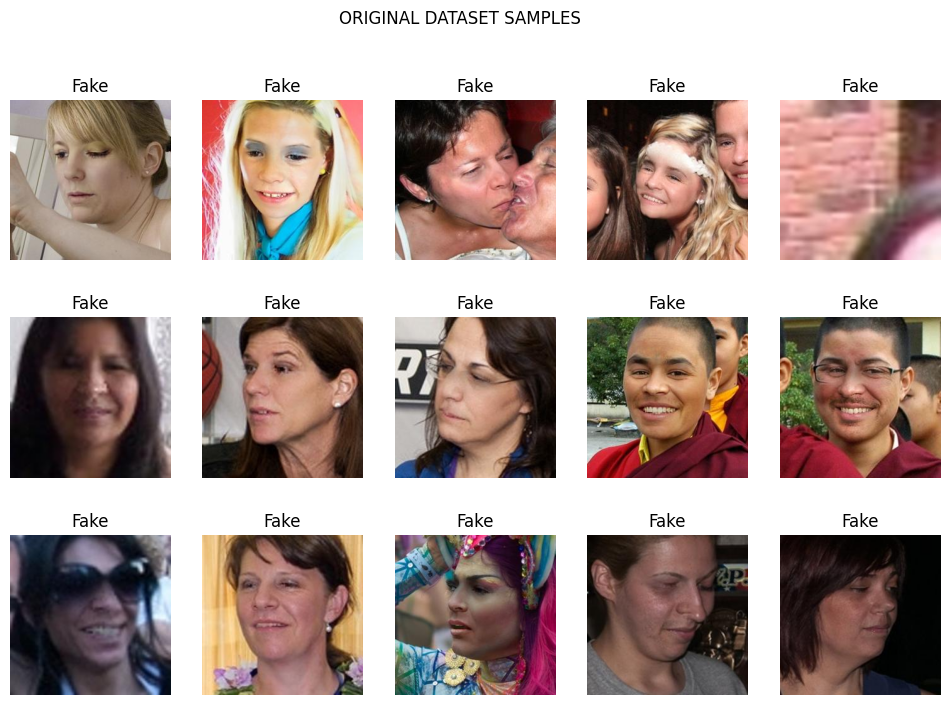

In [7]:
def show_original_samples(dataset, name):
    plt.figure(figsize=(12,8))

    for i in range(15):
        img, label = dataset[i]

        plt.subplot(3,5,i+1)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.suptitle(name)
    plt.show()

show_original_samples(raw_dataset, "ORIGINAL DATASET SAMPLES")

In [8]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

In [9]:
# ImageNet mean-std normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation / Test transforms (NO augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [10]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
import random

# Load full dataset
train_dataset_full = ImageFolder("Dataset/Train")

# Create balanced subset (5000 per class)
def get_subset(dataset, max_per_class=5000):
    class_indices = {0: [], 1: []}  # 0=Fake, 1=Real

    for idx, (_, label) in enumerate(dataset):
        if len(class_indices[label]) < max_per_class:
            class_indices[label].append(idx)

    indices = class_indices[0] + class_indices[1]
    random.shuffle(indices)

    return Subset(dataset, indices)

train_dataset = get_subset(train_dataset_full, 5000)

print("Train subset size:", len(train_dataset))

Train subset size: 10000


In [11]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size

train_dataset, test_dataset = random_split(
    train_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Test size: 2000


In [12]:
from collections import Counter
import matplotlib.pyplot as plt

def get_class_distribution(dataset, name):
    labels = [dataset[i][1] for i in range(len(dataset))]
    count = Counter(labels)

    print(f"\n{name} Distribution:")
    print("Fake:", count[0])
    print("Real:", count[1])

    return count

train_count = get_class_distribution(train_dataset, "TRAIN")
test_count  = get_class_distribution(test_dataset, "TEST")


TRAIN Distribution:
Fake: 4010
Real: 3990

TEST Distribution:
Fake: 990
Real: 1010


In [13]:
def check_balance(count, name):
    total = count[0] + count[1]
    print(f"\n{name} Balance Check:")

    print(f"Fake %: {count[0]/total:.2f}")
    print(f"Real %: {count[1]/total:.2f}")

    if abs(count[0] - count[1]) < 0.05 * total:
        print("✔ Dataset is BALANCED")
    else:
        print("⚠ Dataset is NOT balanced")

check_balance(train_count, "TRAIN")
check_balance(test_count, "TEST")


TRAIN Balance Check:
Fake %: 0.50
Real %: 0.50
✔ Dataset is BALANCED

TEST Balance Check:
Fake %: 0.49
Real %: 0.51
✔ Dataset is BALANCED


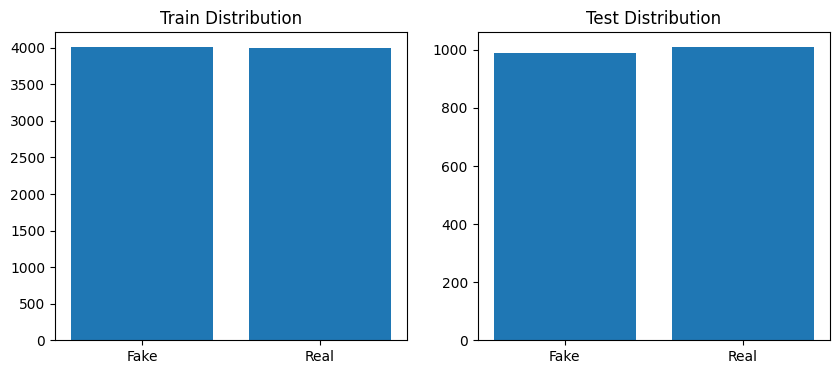

In [14]:
def plot_distribution(train_count, test_count):
    labels = ["Fake", "Real"]

    x = range(len(labels))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.bar(labels, [train_count[0], train_count[1]])
    plt.title("Train Distribution")

    plt.subplot(1,2,2)
    plt.bar(labels, [test_count[0], test_count[1]])
    plt.title("Test Distribution")

    plt.show()

plot_distribution(train_count, test_count)

In [15]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        img = self.transform(img)
        return img, label

In [16]:
# ImageNet mean-std normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation / Test transforms (NO augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [17]:
train_dataset = TransformSubset(train_dataset, train_transforms)
test_dataset  = TransformSubset(test_dataset, val_test_transforms)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [19]:
from collections import Counter

def print_dataset_info(dataset, name):
    print(f"\n===== {name} DATASET INFO =====")

    print("Total samples:", len(dataset))

    labels = [dataset[i][1] for i in range(len(dataset))]
    count = Counter(labels)

    class_names = dataset.dataset.classes if hasattr(dataset, "dataset") else ["Fake", "Real"]

    for i, cls in enumerate(class_names):
        print(f"{cls}: {count[i]}")

    print("\nClass Balance Ratio:")
    total = len(dataset)

    for i, cls in enumerate(class_names):
        print(f"{cls}: {count[i]/total:.4f}")

In [20]:


images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

img, label = train_dataset[0]
print("Image shape:", img.shape)

print_dataset_info(train_dataset, "TRAIN (SUBSET)")
print_dataset_info(test_dataset, "TEST")


Batch image shape: torch.Size([8, 3, 224, 224])
Batch labels shape: torch.Size([8])
Image shape: torch.Size([3, 224, 224])

===== TRAIN (SUBSET) DATASET INFO =====
Total samples: 8000
Fake: 4010
Real: 3990

Class Balance Ratio:
Fake: 0.5012
Real: 0.4988

===== TEST DATASET INFO =====
Total samples: 2000
Fake: 990
Real: 1010

Class Balance Ratio:
Fake: 0.4950
Real: 0.5050


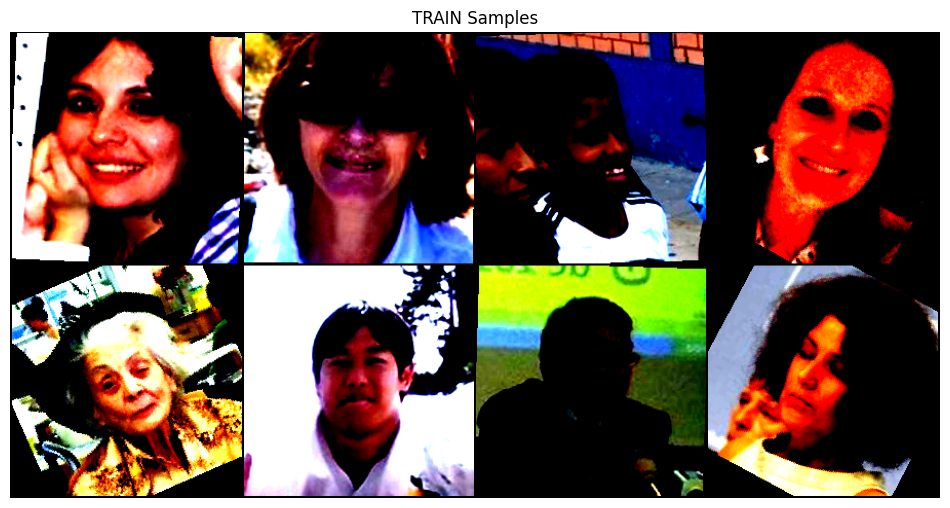

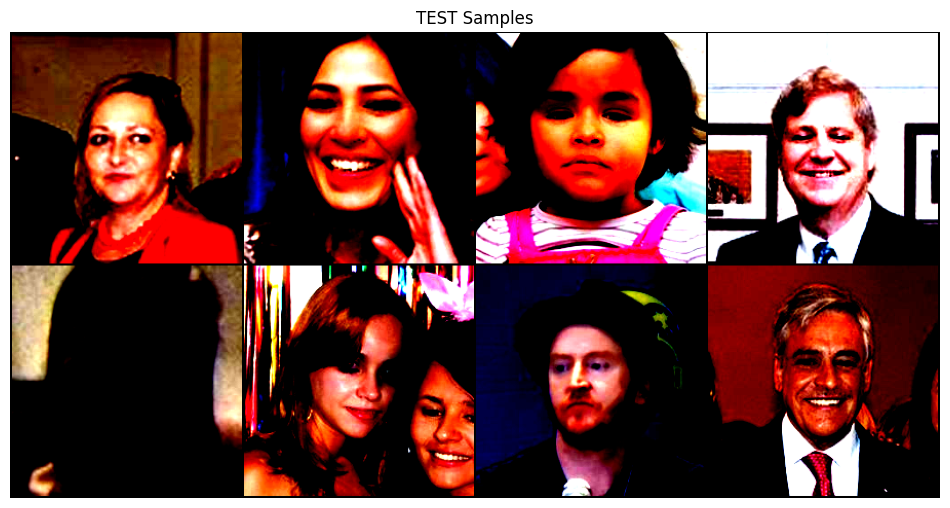

In [ ]:
import torchvision
import torch

def show_samples(dataset, name):
    images = []
    labels = []

    for i in range(8):
        img, label = dataset[i]
        images.append(img)
        labels.append(label)

    grid = torchvision.utils.make_grid(images, nrow=4)

    plt.figure(figsize=(12,8))
    plt.imshow(grid.permute(1,2,0))
    plt.title(f"{name} Samples")
    plt.axis("off")
    plt.show()

show_samples(train_dataset, "TRAIN")
show_samples(test_dataset, "TEST")

In [21]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [22]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

 Device: cpu


Using device: cpu
Epoch [1/10] Loss: 0.3385 Train Acc: 0.8524 Test Acc: 0.9175 LR: 0.000100
Epoch [2/10] Loss: 0.2327 Train Acc: 0.9079 Test Acc: 0.9235 LR: 0.000100
Epoch [3/10] Loss: 0.2138 Train Acc: 0.9177 Test Acc: 0.9385 LR: 0.000100
Epoch [4/10] Loss: 0.1739 Train Acc: 0.9375 Test Acc: 0.9420 LR: 0.000100
Epoch [5/10] Loss: 0.1573 Train Acc: 0.9433 Test Acc: 0.9465 LR: 0.000100
Epoch [6/10] Loss: 0.1493 Train Acc: 0.9484 Test Acc: 0.9475 LR: 0.000100
Epoch [7/10] Loss: 0.1265 Train Acc: 0.9565 Test Acc: 0.9485 LR: 0.000100
Epoch [8/10] Loss: 0.1061 Train Acc: 0.9626 Test Acc: 0.9255 LR: 0.000100
Epoch [9/10] Loss: 0.1163 Train Acc: 0.9601 Test Acc: 0.9450 LR: 0.000100
Epoch [10/10] Loss: 0.1019 Train Acc: 0.9660 Test Acc: 0.9425 LR: 0.000050

Classification Report:

              precision    recall  f1-score   support

        Fake       0.98      0.90      0.94       990
        Real       0.91      0.99      0.95      1010

    accuracy                           0.94      200

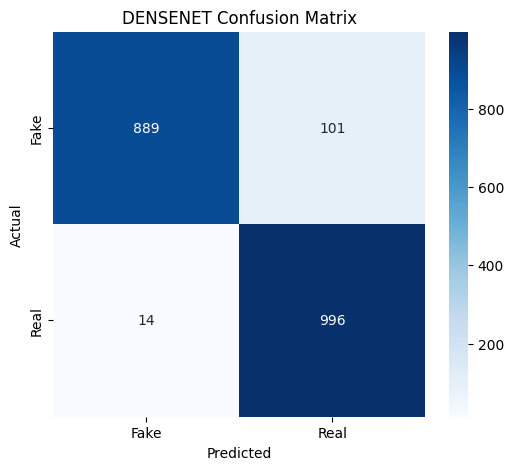

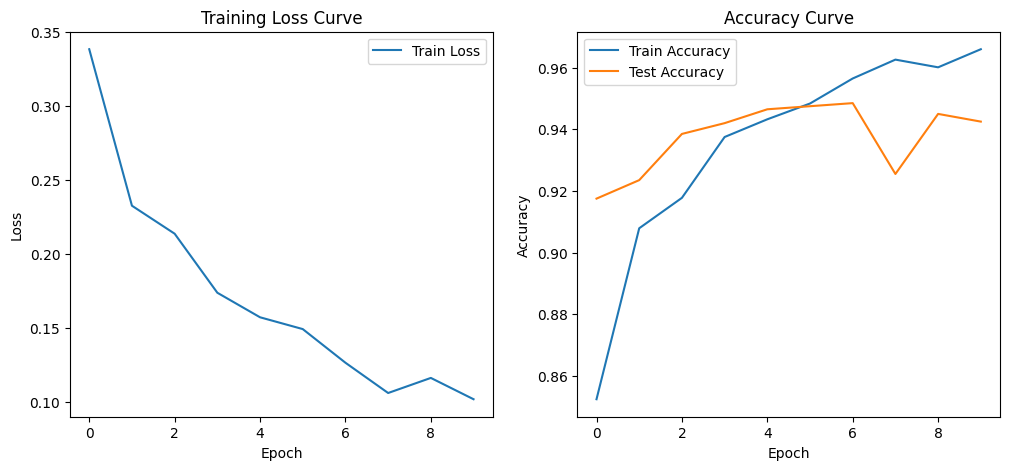


Training Complete!
Best Test Accuracy: 0.9485

Saved Files:
densenet_best_weights.pth
densenet_full_model.pth


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# SELECT MODEL
# =========================
MODEL_NAME = "densenet"

# =========================
# LOAD PRETRAINED MODEL
# =========================
if MODEL_NAME == "densenet":

    model = models.densenet121(pretrained=True)

    # Replace classifier
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, 2)

    # ==========================================
    # PARTIAL FINE-TUNING (FAST + GOOD ACCURACY)
    # Freeze all feature layers
    # ==========================================
    for param in model.features.parameters():
        param.requires_grad = False

    # ==========================================
    # Unfreeze LAST dense block
    # ==========================================
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True

    # classifier trainable
    for param in model.classifier.parameters():
        param.requires_grad = True


elif MODEL_NAME == "inception":

    model = models.inception_v3(pretrained=True)

    # Replace final fc layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    # ==========================================
    # Freeze backbone
    # ==========================================
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze final layer
    for param in model.fc.parameters():
        param.requires_grad = True

model = model.to(device)

# =========================
# LOSS FUNCTION
# =========================
criterion = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# Only trainable parameters
# =========================
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

# =========================
# LEARNING RATE SCHEDULER
# =========================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.5
)

# =========================
# TRAINING SETTINGS
# =========================
num_epochs = 10

train_losses = []
train_accuracies = []

val_accuracies = []

best_acc = 0.0

# =========================
# TRAINING LOOP
# =========================
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Inception special handling
        if MODEL_NAME == "inception":

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

        else:
            outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_acc)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if MODEL_NAME == "inception" and isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    val_acc = correct / total

    val_accuracies.append(val_acc)

    # =========================
    # UPDATE SCHEDULER
    # =========================
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Train Acc: {epoch_acc:.4f} "
          f"Test Acc: {val_acc:.4f} "
          f"LR: {current_lr:.6f}")

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(model.state_dict(),
                   f"{MODEL_NAME}_best_weights.pth")

        torch.save(model,
                   f"{MODEL_NAME}_full_model.pth")

# =========================
# FINAL REPORT
# =========================
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Fake", "Real"]
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{MODEL_NAME.upper()} Confusion Matrix")

plt.show()

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,5))

# LOSS CURVE
plt.subplot(1,2,1)

plt.plot(train_losses, label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()

# ACCURACY CURVE
plt.subplot(1,2,2)

plt.plot(train_accuracies, label="Train Accuracy")

plt.plot(val_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

print("\nTraining Complete!")
print("Best Test Accuracy:", best_acc)

print("\nSaved Files:")
print(f"{MODEL_NAME}_best_weights.pth")
print(f"{MODEL_NAME}_full_model.pth")

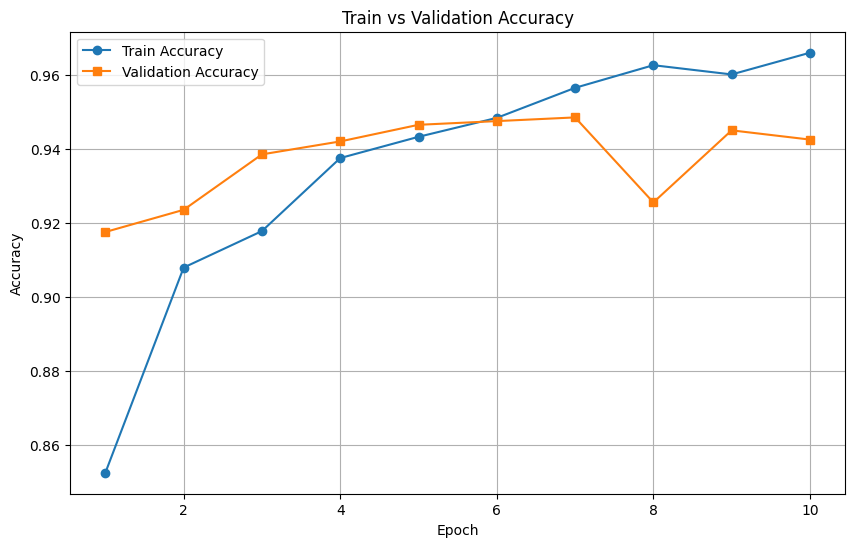

In [36]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10,6))

plt.plot(epochs, train_accuracies, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accuracies, label="Validation Accuracy", marker='s')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Deepfake Detection Model (DenseNet121 and InceptionV3)

## Overview
This project trains a deep learning model to classify images as Fake or Real using transfer learning.

## Model Details
- Backbone: DenseNet121 & InceptionV3 (ImageNet pretrained)
- Fine-tuning: Last dense block unfrozen
- Loss: CrossEntropyLoss
- Optimizer: Adam
- Learning Rate Scheduler: ReduceLROnPlateau

## Evaluation Metrics
The model is evaluated using:
- Accuracy (Train / Validation / Test)
- Confusion Matrix
- Classification Report
- ROC Curve + AUC Score
- t-SNE feature visualization
- Grad-CAM explainability maps

## Output Files
All outputs are saved to Google Drive:
- Model weights (.pth)
- Training curves (.png)
- Confusion matrix (.png)
- ROC curve (.png)
- t-SNE plot (.png)
- Grad-CAM visualizations (.png)

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os

save_dir = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results"

os.makedirs(save_dir, exist_ok=True)

print("Files will be saved in:", save_dir)

Files will be saved in: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results


In [27]:
# SAVE BEST MODEL
if val_acc > best_acc:

    best_acc = val_acc

    weights_path = os.path.join(
        save_dir,
        f"{MODEL_NAME}_best_weights.pth"
    )

    model_path = os.path.join(
        save_dir,
        f"{MODEL_NAME}_full_model.pth"
    )

    torch.save(model.state_dict(), weights_path)

    torch.save(model, model_path)

    print("Model saved!")

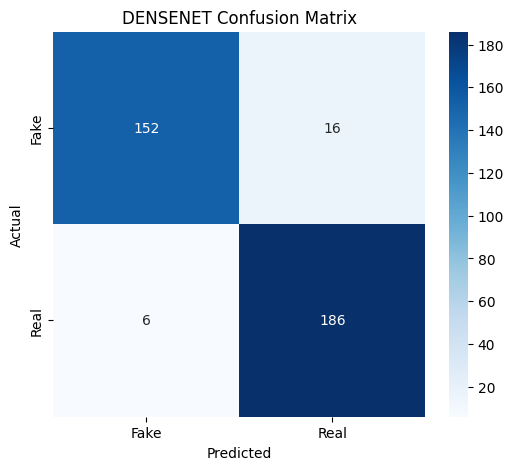

Confusion matrix saved!


In [44]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{MODEL_NAME.upper()} Confusion Matrix")

# SAVE IMAGE
cm_path = os.path.join(
    save_dir,
    f"{MODEL_NAME}_confusion_matrix.png"
)

plt.savefig(cm_path, dpi=300, bbox_inches='tight')

plt.show()

print("Confusion matrix saved!")

In [29]:
# =========================
# CLASSIFICATION REPORT
# =========================

report = classification_report(
    all_labels,
    all_preds,
    target_names=["Fake", "Real"]
)

print("\nClassification Report:\n")
print(report)

# SAVE REPORT
report_path = os.path.join(
    save_dir,
    f"{MODEL_NAME}_classification_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

print("Classification report saved!")


Classification Report:

              precision    recall  f1-score   support

        Fake       0.98      0.90      0.94       990
        Real       0.91      0.99      0.95      1010

    accuracy                           0.94      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.95      0.94      0.94      2000

Classification report saved!


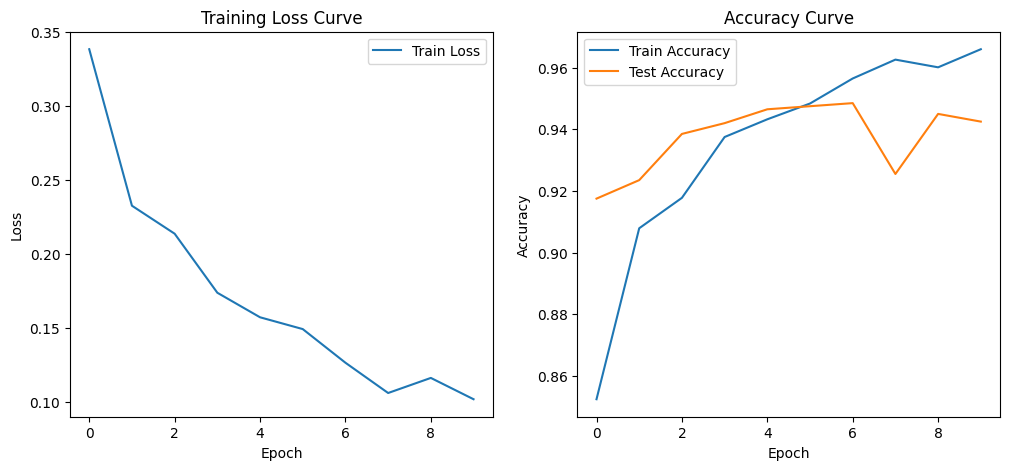

Training curves saved!


In [30]:
# =========================
# TRAINING CURVES
# =========================

plt.figure(figsize=(12,5))

# LOSS CURVE
plt.subplot(1,2,1)

plt.plot(train_losses, label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()

# ACCURACY CURVE
plt.subplot(1,2,2)

plt.plot(train_accuracies, label="Train Accuracy")

plt.plot(val_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

# SAVE IMAGE
curve_path = os.path.join(
    save_dir,
    f"{MODEL_NAME}_training_curves.png"
)

plt.savefig(curve_path, dpi=300, bbox_inches='tight')

plt.show()

print("Training curves saved!")

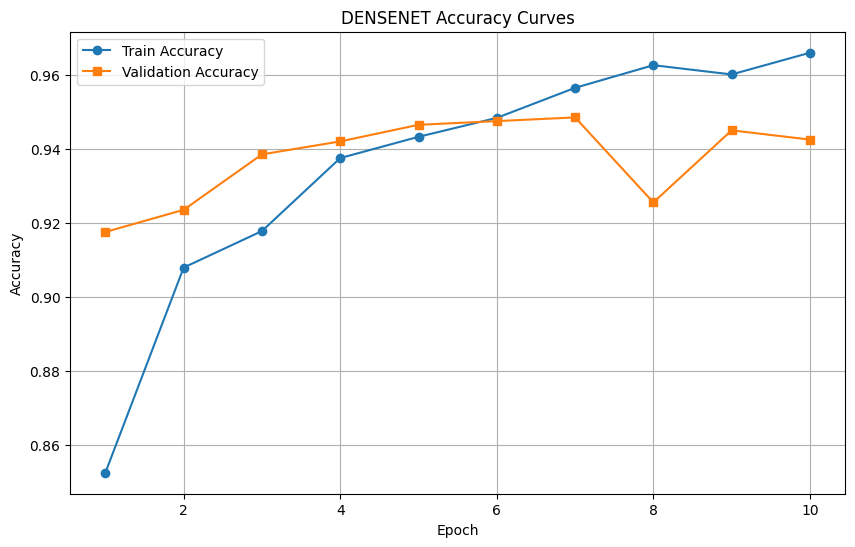

Accuracy curves saved!


In [35]:
# =========================
# ACCURACY CURVES
# =========================

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10,6))

# TRAIN
plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label="Train Accuracy"
)

# VALIDATION
plt.plot(
    epochs,
    val_accuracies,
    marker='s',
    label="Validation Accuracy"
)

# # TEST LINE
# plt.axhline(
#     y=test_acc,
#     linestyle='--',
#     label=f"Final Test Accuracy = {test_acc:.4f}"
# )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(f"{MODEL_NAME.upper()} Accuracy Curves")

plt.legend()

plt.grid(True)

# SAVE GRAPH
curve_path = os.path.join(
    save_dir,
    f"{MODEL_NAME}_training_curves.png"
)

plt.savefig(curve_path, dpi=300, bbox_inches='tight')

plt.show()

print("Accuracy curves saved!")

In [37]:
import numpy as np

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

wrong_idx = np.where(all_preds != all_labels)[0]

print("Total wrong predictions:", len(wrong_idx))
print("Error rate:", len(wrong_idx) / len(all_labels))

Total wrong predictions: 22
Error rate: 0.06111111111111111


In [41]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        if MODEL_NAME == "dense" and isinstance(outputs, tuple):
            outputs = outputs[0]

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9425


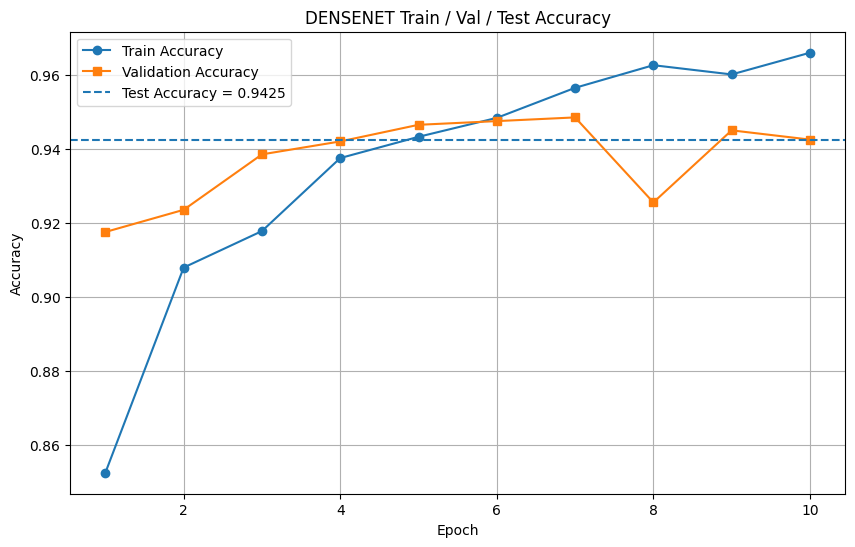

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/densenet_train_val_test_curve.png


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# ACCURACY CURVES (ALL 3)
# =========================

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10,6))

# TRAIN ACCURACY
plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label="Train Accuracy"
)

# VALIDATION ACCURACY
plt.plot(
    epochs,
    val_accuracies,
    marker='s',
    label="Validation Accuracy"
)

# TEST ACCURACY (horizontal line)
plt.axhline(
    y=test_acc,
    linestyle='--',
    label=f"Test Accuracy = {test_acc:.4f}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_NAME.upper()} Train / Val / Test Accuracy")

plt.legend()
plt.grid(True)

# SAVE
curve_path = os.path.join(
    save_dir,
    f"{MODEL_NAME}_train_val_test_curve.png"
)

plt.savefig(curve_path, dpi=300, bbox_inches='tight')

plt.show()

print("Saved:", curve_path)

In [43]:
from sklearn.manifold import TSNE

model.eval()

features = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # extract features before classifier
        feat = model.features(images)
        feat = torch.nn.functional.adaptive_avg_pool2d(feat, (1,1))
        feat = feat.view(feat.size(0), -1)

        features.append(feat.cpu().numpy())
        labels_list.append(labels.numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

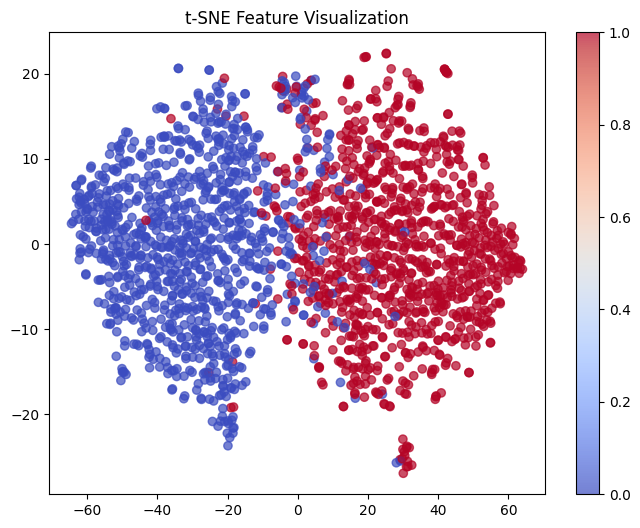

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/tsne.png


In [50]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(8,6))

plt.scatter(tsne_results[:,0],
            tsne_results[:,1],
            c=labels_list,
            cmap='coolwarm',
            alpha=0.7)

plt.title("t-SNE Feature Visualization")
plt.colorbar()

tsne_path = os.path.join(save_dir, "tsne.png")
plt.savefig(tsne_path, dpi=300, bbox_inches='tight')

plt.show()

print("Saved:", tsne_path)

In [53]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # forward hook
        target_layer.register_forward_hook(self.forward_hook)

        # backward hook (SAFE version)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx=None):

        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2,3))[0]

        cam = torch.zeros(self.activations.shape[2:], device=x.device)

        for i, w in enumerate(weights):
            cam += w * self.activations[0, i]

        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.cpu().detach().numpy()

In [54]:
# choose layer (last conv block)
target_layer = model.features.denseblock4

cam = GradCAM(model, target_layer)

images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

heatmap = cam.generate(img)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_716/4128863961.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output[0, class_idx].backward()


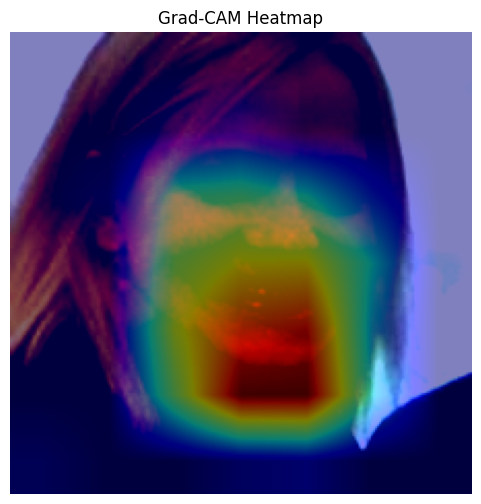

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/gradcam_heatmap.png


In [55]:
# convert image
img_np = images[0].permute(1,2,0).numpy()

# resize heatmap
heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))

plt.figure(figsize=(6,6))

plt.imshow(img_np)

plt.imshow(heatmap, cmap='jet', alpha=0.5)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

# SAVE
gradcam_path = os.path.join(save_dir, "gradcam_heatmap.png")
plt.savefig(gradcam_path, dpi=300, bbox_inches='tight')

plt.show()

print("Saved:", gradcam_path)

**Model:** EfficientNet-B3
**Input Size: **224 × 224 × 3

**Architecture:**
- Convolutional Neural Network (CNN)
- Compound scaling (depth, width, resolution)

**Details:**
- Total Parameters: 12M
- Feature Extractor: Pretrained on ImageNet
- Classifier Head: Custom binary classifier (1 output)

**Weights Initialization:**
- Backbone: Pretrained (ImageNet)
- Classifier: Random initialization

**Fine-Tuning Strategy:**
- Frozen Layers: Feature extractor (initial training)
- Trainable Layers: Final classifier layer

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

target_layer = model.conv_head  # EfficientNet-B3

cam = GradCAM(model=model, target_layers=[target_layer])

In [ ]:
img, label = test_dataset[0]

input_tensor = img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

In [ ]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

img_np = denormalize(img).permute(1,2,0).cpu().numpy()

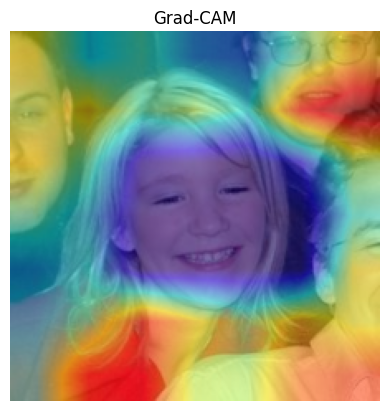

In [ ]:
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")
plt.show()